# Risk-Adjusted Performance Analysis — Indian Stocks vs Nifty 50
**Tools:** Python, yfinance, pandas, matplotlib  
**Stocks analysed:** TCS, HDFC Bank, Reliance, Infosys vs Nifty 50 Index  
**Period:** January 2021 — January 2025

## Objective
Most investors assume picking individual blue-chip stocks beats the market. 
This project tests that assumption using actual data — comparing risk-adjusted 
returns (Sharpe Ratio) and benchmark-relative performance (Excess Return/Alpha) 
of four major Indian stocks against the Nifty 50 index over 4 years.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
stocks = yf.download(["TCS.NS", "HDFCBANK.NS","RELIANCE.NS","INFY.NS","^NSEI"], 
            start = "2021-01-01", end = "2025-01-01")

[*********************100%***********************]  5 of 5 completed


## Calculating Daily Returns
Converting raw closing prices into daily percentage returns for all five tickers

In [3]:
close = stocks["Close"]

In [4]:
returns = close.pct_change()

## Cumulative Returns — Growth of ₹1 Invested
Normalising all five (4 stocks + Nifty) to compare performance fairly

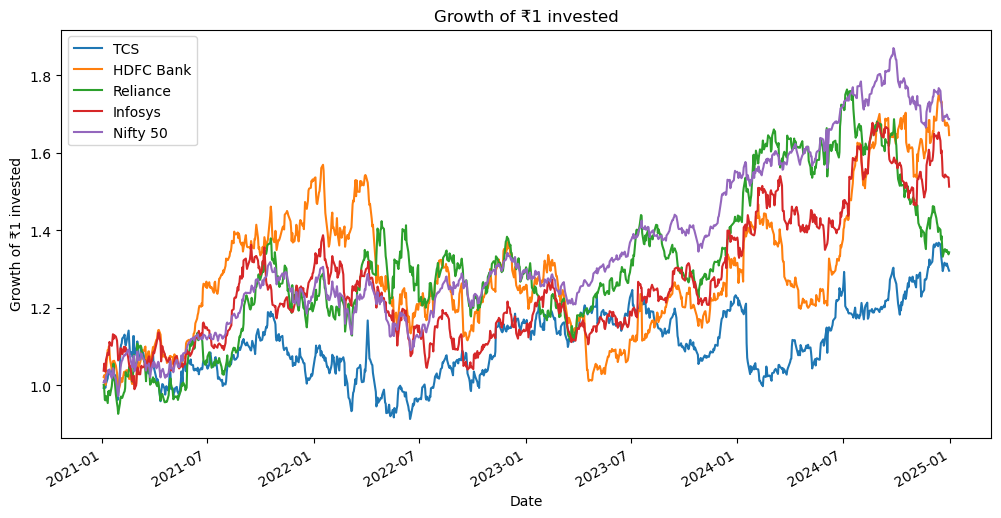

In [5]:
cumulative = (1 + returns).cumprod()
cumulative.plot(title = "Growth of ₹1 invested",
                figsize = (12,6) )
plt.xlabel("Date")
plt.ylabel("Growth of ₹1 invested")
plt.legend(["TCS", "HDFC Bank", "Reliance", "Infosys", "Nifty 50"])
plt.show()


## Risk-Adjusted Return — Sharpe Ratio
Sharpe Ratio measures return earned per unit of risk taken, using 
India's risk-free rate (10Y G-Sec ~7%) as the baseline comparison

In [6]:
annual_return = returns.mean() * 252
annual_volatility = returns.std() * (252**0.5)

risk_free_rate = 0.07
sharpe_ratio = (annual_return-risk_free_rate)/annual_volatility

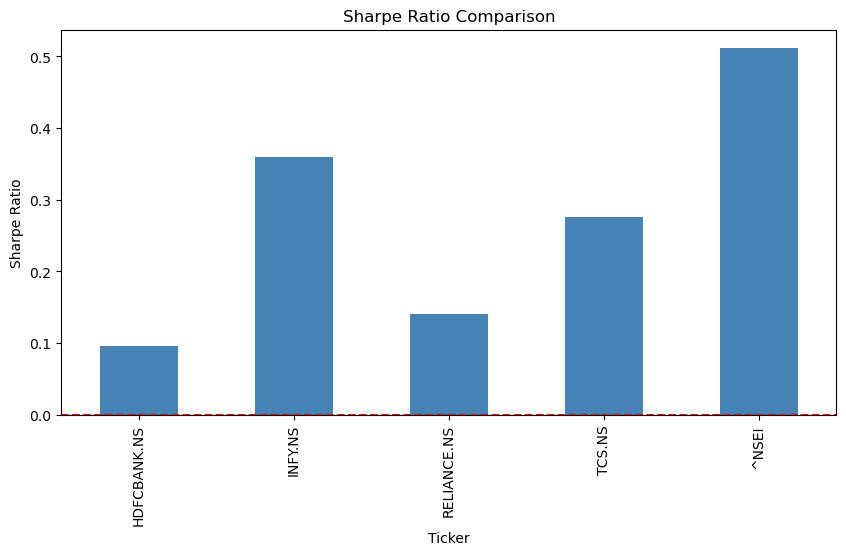

In [7]:
sharpe_ratio.plot(kind='bar', figsize=(10,5), color='steelblue')
plt.title("Sharpe Ratio Comparison")
plt.ylabel("Sharpe Ratio")
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

## Maximum Drawdown
Sharpe Ratio shows average risk-adjusted return, but doesn't capture how bad the worst losing period was. 
Maximum Drawdown measures the largest peak-to-trough decline an investor would have experienced — a critical risk metric that complements Sharpe Ratio.

In [8]:
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min()

## Summary Table — Complete Risk-Return Profile
Combining all metrics into a single comparison table: Return, Volatility, 
Excess Return (Alpha vs Nifty), and Maximum Drawdown — giving a full 
risk-return picture for each stock and the benchmark

In [9]:
summary = pd.DataFrame({"Return": annual_return, "Volatility": annual_volatility})
summary["Max Drawdown"] = max_drawdown
summary["Excess Return"] = (summary["Return"] - summary.loc["^NSEI", "Return"])

In [10]:
summary

,Return,Volatility,Max Drawdown,Excess Return
Ticker,,,,
HDFCBANK.NS,0.091425,0.224477,-0.232429,-0.052732
INFY.NS,0.155777,0.238226,-0.355572,0.011620
RELIANCE.NS,0.102960,0.234799,-0.244556,-0.041197
TCS.NS,0.127767,0.209757,-0.249754,-0.016390
^NSEI,0.144157,0.144908,-0.172298,0.000000


## Correlation Matrix
Shows how closely each stock's daily movements match every other stock 
and the index — lower correlation between holdings means better diversification

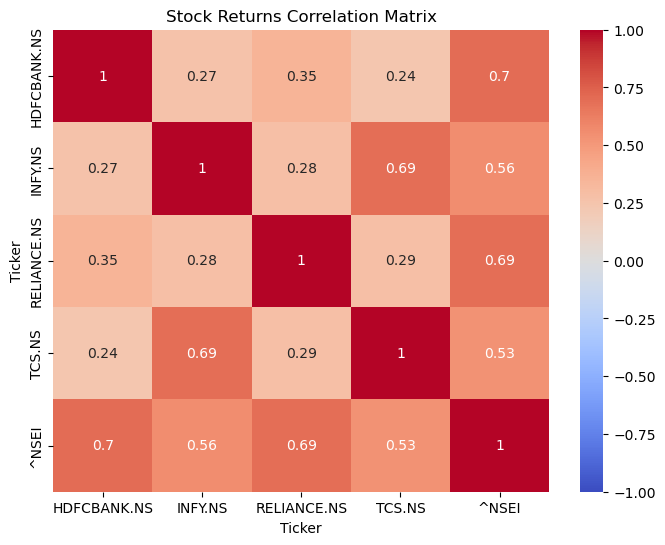

In [11]:
correlation = returns.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True,cmap ="coolwarm", vmin=-1, vmax=1)
plt.title("Stock Returns Correlation Matrix")
plt.show()

## Key Findings

**Sharpe Ratio (risk-adjusted return ranking):**
- Nifty 50: 0.51 (best)
- Infosys: 0.36
- TCS: 0.28
- Reliance: 0.14
- HDFC Bank: 0.10 (worst)

**Maximum Drawdown:**
- Infosys: -35.6% — largest peak-to-trough loss of any stock
- TCS: -25.0%
- Reliance: -24.5%
- HDFC Bank: -23.2%
- Nifty 50: -17.2% — smallest drawdown by a wide margin, confirming 
  every individual stock carried more downside risk than the index

**Excess Return vs Nifty (Alpha):**
- Only Infosys beat the Nifty 50 (+1.16%)
- TCS, Reliance, and HDFC Bank all underperformed the index
- HDFC Bank lagged the most, by over 5%

**The Infosys paradox:**
Infosys posted the best Sharpe Ratio and the only positive Excess Return 
among individual stocks, yet also suffered the worst drawdown at -35.6%. 
This shows that strong risk-adjusted returns don't guarantee a smooth ride — 
an investor holding Infosys would have experienced a much deeper loss at 
some point than an investor holding the index, even though Infosys's 
overall outcome was better.

**Conclusion:**
Across every risk metric tested — Sharpe Ratio, Excess Return, and Maximum 
Drawdown — the Nifty 50 index consistently showed better or comparable 
risk-adjusted performance than individual blue-chip stocks, while carrying 
significantly less downside risk. Despite being considered safe blue-chip 
investments, three of four individual stocks failed to beat the index on 
a risk-adjusted basis over 2021-2025. This reinforces the case for passive, 
diversified investing over individual stock picking for most investors.

**Correlation:**
- HDFC Bank and Nifty have the highest correlation (0.70) — unsurprising 
  given HDFC Bank's large weight in the index
- TCS and Infosys move closely together (0.69) — both being IT sector stocks
- This shows holding both TCS and Infosys provides less diversification 
  benefit than holding stocks from different sectors